In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = ['checking_status','duration','credit_history','purpose','credit_amount',
           'savings_status','employment','installment_rate','personal_status',
           'other_parties','residence_since','property_magnitude','age',
           'other_payment_plans','housing','existing_credits','job',
           'num_dependents','own_telephone','foreign_worker','class']

df = pd.read_csv(url, sep=' ', header=None, names=columns)
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [ ]:
checking_status_map = {'A11':'<0', 'A12':'0<=X<200', 'A13':'>=200', 'A14':'no_checking'}
credit_history_map = {'A30':'no_credits', 'A31':'all_paid', 'A32':'existing_paid',
                       'A33':'delayed', 'A34':'critical'}
purpose_map = {'A40':'car_new','A41':'car_used','A42':'furniture','A43':'radio_tv',
               'A44':'appliances','A45':'repairs','A46':'education','A47':'vacation',
               'A48':'retraining','A49':'business','A410':'other'}
savings_status_map = {'A61':'<100','A62':'100<=X<500','A63':'500<=X<1000',
                       'A64':'>=1000','A65':'no_savings'}
employment_map = {'A71':'unemployed','A72':'<1yr','A73':'1<=X<4yr',
                   'A74':'4<=X<7yr','A75':'>=7yr'}
personal_status_map = {'A91':'male_divorced','A92':'female_div/mar',
                        'A93':'male_single','A94':'male_mar/wid','A95':'female_single'}
other_parties_map = {'A101':'none','A102':'co-applicant','A103':'guarantor'}
property_map = {'A121':'real_estate','A122':'life_insurance',
                 'A123':'car_other','A124':'no_property'}
other_payment_plans_map = {'A141':'bank','A142':'stores','A143':'none'}
housing_map = {'A151':'rent','A152':'own','A153':'free'}
job_map = {'A171':'unskilled_nonres','A172':'unskilled_res',
           'A173':'skilled','A174':'high_qualif'}
telephone_map = {'A191':'none','A192':'yes'}
foreign_worker_map = {'A201':'yes','A202':'no'}

df['checking_status'] = df['checking_status'].map(checking_status_map)
df['credit_history'] = df['credit_history'].map(credit_history_map)
df['purpose'] = df['purpose'].map(purpose_map)
df['savings_status'] = df['savings_status'].map(savings_status_map)
df['employment'] = df['employment'].map(employment_map)
df['personal_status'] = df['personal_status'].map(personal_status_map)
df['other_parties'] = df['other_parties'].map(other_parties_map)
df['property_magnitude'] = df['property_magnitude'].map(property_map)
df['other_payment_plans'] = df['other_payment_plans'].map(other_payment_plans_map)
df['housing'] = df['housing'].map(housing_map)
df['job'] = df['job'].map(job_map)
df['own_telephone'] = df['own_telephone'].map(telephone_map)
df['foreign_worker'] = df['foreign_worker'].map(foreign_worker_map)

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical,radio_tv,1169,no_savings,>=7yr,4,male_single,none,...,real_estate,67,none,own,2,skilled,1,yes,yes,1
1,0<=X<200,48,existing_paid,radio_tv,5951,<100,1<=X<4yr,2,female_div/mar,none,...,real_estate,22,none,own,1,skilled,1,none,yes,2
2,no_checking,12,critical,education,2096,<100,4<=X<7yr,2,male_single,none,...,real_estate,49,none,own,1,unskilled_res,2,none,yes,1
3,<0,42,existing_paid,furniture,7882,<100,4<=X<7yr,2,male_single,guarantor,...,life_insurance,45,none,free,1,skilled,2,none,yes,1
4,<0,24,delayed,car_new,4870,<100,1<=X<4yr,3,male_single,none,...,no_property,53,none,free,2,skilled,2,none,yes,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   checking_status      1000 non-null   object
 1   duration             1000 non-null   int64 
 2   credit_history       1000 non-null   object
 3   purpose              1000 non-null   object
 4   credit_amount        1000 non-null   int64 
 5   savings_status       1000 non-null   object
 6   employment           1000 non-null   object
 7   installment_rate     1000 non-null   int64 
 8   personal_status      1000 non-null   object
 9   other_parties        1000 non-null   object
 10  residence_since      1000 non-null   int64 
 11  property_magnitude   1000 non-null   object
 12  age                  1000 non-null   int64 
 13  other_payment_plans  1000 non-null   object
 14  housing              1000 non-null   object
 15  existing_credits     1000 non-null   int64 
 16  job    

In [ ]:
df.isnull().sum()

,0
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_rate,0
personal_status,0
other_parties,0


In [ ]:
df['class'].value_counts()

,count
class,
1,700
2,300


In [ ]:
df['class'] = df['class'].map({1: 1, 2: 0})  # 1 = Good, 0 = Bad
df['class'].value_counts()

,count
class,
1,700
0,300


In [ ]:
categorical_cols = ['checking_status','credit_history','purpose','savings_status',
                     'employment','personal_status','other_parties','property_magnitude',
                     'other_payment_plans','housing','job','own_telephone','foreign_worker']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.shape

(1000, 49)

In [ ]:
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(800, 48) (200, 48)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,113 (8.25 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train_scaled, y_train,
                     validation_split=0.2,
                     epochs=100,
                     batch_size=16,
                     callbacks=[early_stop],
                     verbose=1)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5109 - loss: 0.7473 - val_accuracy: 0.6250 - val_loss: 0.6446
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6344 - loss: 0.6463 - val_accuracy: 0.6750 - val_loss: 0.5954
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6922 - loss: 0.6197 - val_accuracy: 0.6875 - val_loss: 0.5699
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7031 - loss: 0.5572 - val_accuracy: 0.6875 - val_loss: 0.5505
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7500 - loss: 0.5490 - val_accuracy: 0.7188 - val_loss: 0.5333
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7359 - loss: 0.5359 - val_accuracy: 0.7188 - val_loss: 0.5171
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7484 - loss: 0.5250 - val_accuracy: 0.7188 - val_loss: 0.5066
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7547 - loss: 0.5142 - val_accuracy: 0.7250 -

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[[ 30  30]
 [ 28 112]]
              precision    recall  f1-score   support

           0       0.52      0.50      0.51        60
           1       0.79      0.80      0.79       140

    accuracy                           0.71       200
   macro avg       0.65      0.65      0.65       200
weighted avg       0.71      0.71      0.71       200

ROC-AUC: 0.7513095238095239


In [ ]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.6666666666666667), 1: np.float64(0.7142857142857143)}


In [ ]:
history = model.fit(X_train_scaled, y_train,
                     validation_split=0.2,
                     epochs=100,
                     batch_size=16,
                     callbacks=[early_stop],
                     class_weight=class_weights,
                     verbose=1)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8109 - loss: 0.4780 - val_accuracy: 0.7812 - val_loss: 0.4444
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8078 - loss: 0.4584 - val_accuracy: 0.7750 - val_loss: 0.4556
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7906 - loss: 0.4506 - val_accuracy: 0.8000 - val_loss: 0.4515
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8047 - loss: 0.4286 - val_accuracy: 0.7688 - val_loss: 0.4572
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7906 - loss: 0.4423 - val_accuracy: 0.7688 - val_loss: 0.4565
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8125 - loss: 0.4177 - val_accuracy: 0.7750 - val_loss: 0.4581
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7875 - loss: 0.4104 - val_accuracy: 0.7750 - val_loss: 0.4528
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8016 - loss: 0.4133 - val_accuracy: 0.7875

In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!echo KGAT_6a2e7ab54d241342719157cdd6806937 > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [ ]:
!kaggle datasets download -d uciml/german-credit
!unzip german-credit.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/german-credit
License(s): DbCL-1.0
100% 10.9k/10.9k [00:00<00:00, 14.4MB/s]

Archive:  german-credit.zip
  inflating: german_credit_data.csv  


In [ ]:
df = pd.read_csv('german_credit_data.csv')
df.head()

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

In [ ]:
df = pd.read_csv('german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = ['checking_status','duration','credit_history','purpose','credit_amount',
           'savings_status','employment','installment_rate','personal_status',
           'other_parties','residence_since','property_magnitude','age',
           'other_payment_plans','housing','existing_credits','job',
           'num_dependents','own_telephone','foreign_worker','class']

df = pd.read_csv(url, sep=' ', header=None, names=columns)
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.utils import class_weight
import tensorflow as tf
from tensorflow import keras

# 1. Load data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = ['checking_status','duration','credit_history','purpose','credit_amount',
           'savings_status','employment','installment_rate','personal_status',
           'other_parties','residence_since','property_magnitude','age',
           'other_payment_plans','housing','existing_credits','job',
           'num_dependents','own_telephone','foreign_worker','class']
df = pd.read_csv(url, sep=' ', header=None, names=columns)

# 2. Decode categorical codes
maps = {
 'checking_status': {'A11':'<0','A12':'0<=X<200','A13':'>=200','A14':'no_checking'},
 'credit_history': {'A30':'no_credits','A31':'all_paid','A32':'existing_paid','A33':'delayed','A34':'critical'},
 'purpose': {'A40':'car_new','A41':'car_used','A42':'furniture','A43':'radio_tv','A44':'appliances',
             'A45':'repairs','A46':'education','A47':'vacation','A48':'retraining','A49':'business','A410':'other'},
 'savings_status': {'A61':'<100','A62':'100<=X<500','A63':'500<=X<1000','A64':'>=1000','A65':'no_savings'},
 'employment': {'A71':'unemployed','A72':'<1yr','A73':'1<=X<4yr','A74':'4<=X<7yr','A75':'>=7yr'},
 'personal_status': {'A91':'male_divorced','A92':'female_div/mar','A93':'male_single','A94':'male_mar/wid','A95':'female_single'},
 'other_parties': {'A101':'none','A102':'co-applicant','A103':'guarantor'},
 'property_magnitude': {'A121':'real_estate','A122':'life_insurance','A123':'car_other','A124':'no_property'},
 'other_payment_plans': {'A141':'bank','A142':'stores','A143':'none'},
 'housing': {'A151':'rent','A152':'own','A153':'free'},
 'job': {'A171':'unskilled_nonres','A172':'unskilled_res','A173':'skilled','A174':'high_qualif'},
 'own_telephone': {'A191':'none','A192':'yes'},
 'foreign_worker': {'A201':'yes','A202':'no'}
}
for col, m in maps.items():
    df[col] = df[col].map(m)

# 3. Target to 0/1
df['class'] = df['class'].map({1: 1, 2: 0})  # 1=Good, 0=Bad

# 4. One-hot encode
categorical_cols = list(maps.keys())
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 5. Split
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Class weights
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))
print("Class weights:", class_weights)

# 8. Build model
model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 9. Train
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train_scaled, y_train,
                     validation_split=0.2,
                     epochs=100,
                     batch_size=16,
                     callbacks=[early_stop],
                     class_weight=class_weights,
                     verbose=1)

# 10. Evaluate
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

Class weights: {0: np.float64(1.6666666666666667), 1: np.float64(0.7142857142857143)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.3828 - loss: 0.7696 - val_accuracy: 0.4125 - val_loss: 0.7576
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5109 - loss: 0.7096 - val_accuracy: 0.5688 - val_loss: 0.6869
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5953 - loss: 0.6513 - val_accuracy: 0.6250 - val_loss: 0.6550
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6047 - loss: 0.6387 - val_accuracy: 0.6625 - val_loss: 0.6309
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6453 - loss: 0.6279 - val_accuracy: 0.7188 - val_loss: 0.6063
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6609 - loss: 0.6049 - val_accuracy: 0.7375 - val_loss: 0.5884
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7047 - loss: 0.5745 - val_accuracy: 0.7312 - val_loss: 0.5685
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7172 - loss: 0.5786 - val_accuracy: 0.

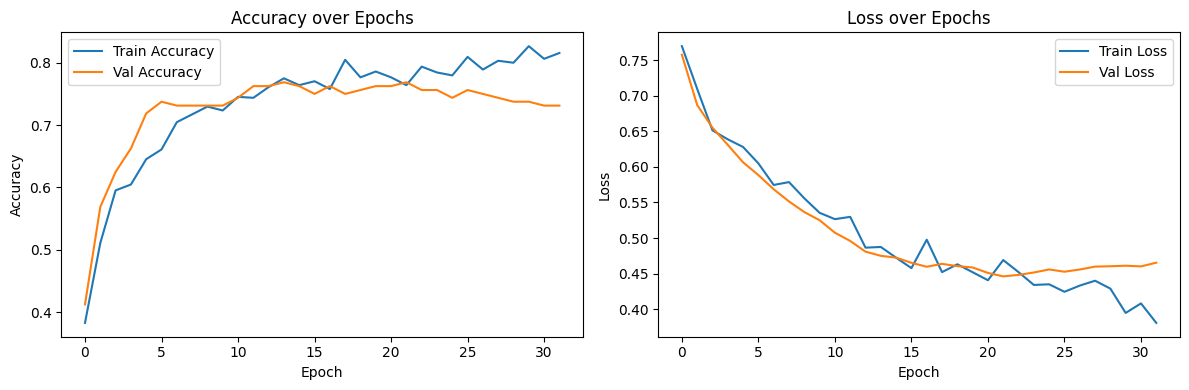

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Training history plot
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

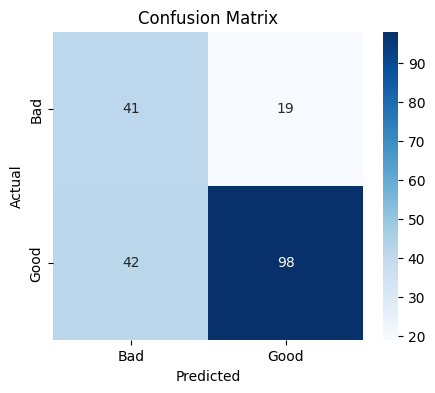

In [ ]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bad','Good'], yticklabels=['Bad','Good'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()

In [ ]:
readme_content = """# Credit Risk Scoring Model using ANN

## Problem Statement
Develop a deep learning model to assess credit risk (good/bad) using demographic and financial data.

## Dataset
German Credit Data (UCI Machine Learning Repository) — 1000 records, 20 features
(checking account status, credit history, purpose, credit amount, duration, employment, etc.)

## Approach
1. Data preprocessing: categorical encoding (one-hot), feature scaling (StandardScaler)
2. Handled class imbalance (70% good / 30% bad) using class weights
3. Built an Artificial Neural Network (ANN) using TensorFlow/Keras:
   - Input layer (48 features)
   - Hidden layer 1: 32 neurons, ReLU, Dropout(0.3)
   - Hidden layer 2: 16 neurons, ReLU, Dropout(0.2)
   - Output layer: 1 neuron, Sigmoid (binary classification)
4. Trained with EarlyStopping to prevent overfitting

## Results
- Accuracy: 69%
- ROC-AUC: 0.74
- Bad-risk recall: 68% (improved from 50% baseline using class weighting)

## Files
- `credit_risk_model.ipynb` — full notebook
- `training_history.png` — accuracy/loss curves
- `confusion_matrix.png` — confusion matrix heatmap

## Tech Stack
Python, Pandas, NumPy, Scikit-learn, TensorFlow/Keras, Matplotlib, Seaborn

## How to Run
1. Open notebook in Google Colab
2. Run all cells sequentially
3. Dataset auto-loads from UCI repository
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README saved!")

README saved!
